In [1]:
import re
import os, json

# dedent : 여러줄 문자열을 코드상 보기 좋게 들여쓰기했을 때, 공통 들여쓰기를 제거하는 함수 (불필요한 앞쪽 공백 제거)
from textwrap import dedent
from pprint import pprint

import warnings

warnings.filterwarnings("ignore")

from dotenv import load_dotenv

load_dotenv()

True

## 2. StateGraph
- 상태(state)를 기반으로 작동하는 그래프 구조
- 실습: 레스토랑 메뉴 추천 시스템
    - 사용자의 선호도에 따라 메뉴를 추천하고, 메뉴에 대한 정보를 제공

`(1) 상태(State)`
- 상태는 그래프가 처리하는 데이터의 구조를 정의
- 기존 상태를 override (덮어쓰기)
- TypedDict or Pydantic BaseMOdel 사용
- 시스템의 전체 컨텍스트를 포함

`(2) 노드(Node)`
- Agent의 로직을 인코딩하는 python 함수
- 현재 state를 입력으로 받고, 계산이나 부작용(side-effect)를 수행한 후, 업데이트된 state를 반환

`(3) 엣지(Edge)`
- 현재 state를 기반으로 다음에 실행할 Node를 결정하는 함수
- 조건부 분기 or 고정전히
- 시스템의 흐름을 제어

```
class OverallState(BaseModel):
    text: str

def node(state: OverallState):
    return {"text" : "반값습니다."}

# 그래프 만들기(엣지로 연결)
builder = StateGraph(OverallState)
builder.add_node(node)
builder.add_edge(START, "node")
builder.add_edge("node", END)

graph = builder.compile()

graph.invoke({"text":"안녕하세요."})

```

### (1) State

In [1]:
from typing import TypedDict
from pydantic import BaseModel
# state schema definition : user's preference, recommended menu, menu information
class MenuState(TypedDict):
    user_preference: str
    recommended_menu: str
    menu_info: str

### (2) Node Function
- 노드: 그래프에서 state를 입력받아 작업을 수행후에 updated state를 반환

In [2]:
import random

def get_user_preference(state: MenuState) -> MenuState:
    print("-- 랜던 사용자 선호도 생성 --")
    preferences = ["육류", "해산물", "채식", "아무거나"]
    preference = random.choice(preferences)
    print(f"생성된 선호도: {preference}")

    return {"user_preference": preference}

def recommend_menu(state: MenuState) -> MenuState:
    print("-- 메뉴 추천 --")
    preference = state["user_preference"]

    if preference == "육류":
        menu = "스테이크"
    elif preference == "해산물":
        menu = "랍스터 파스타"
    elif preference == "채식":
        menu = "그린 샐러드"
    else:
        menu ="오늘의 쉐프 특선"

    print(f"추천 메뉴: {menu}")

    return {"recommended_menu": menu}

def provide_menu_info(state: MenuState) -> MenuState:
    print("-- 메뉴 정보 제공 --")
    menu = state["recommended_menu"]

    if menu == "스테이크":
        info = "최상급 소고기로 만든 juicy한 스테이크입니다. 가격: 30,000원"
    elif menu == "랍스터 파스타":
        info = "신선한 랍스터와 al dente 파스타의 조화. 가격: 28,000원"
    elif menu == "그린 샐러드":
        info = "신선한 유기농 채소로 만든 건강한 샐러드. 가격: 15,000원"
    else:
        info = "쉐프가 그날그날 엄선한 특별 요리입니다. 가격: 35,000원"
    print(f"메뉴 정보: {info}")
    return {"menu_info": info}

### (3) Graph
- 정의한 구성 요소들을 사용하여 전체 그래프를 빌드

In [3]:
from langgraph.graph import StateGraph, START, END

# Graph Builder
builder = StateGraph(MenuState)

# Add nodes
builder.add_node("get_preference", get_user_preference)
builder.add_node("recommend", recommend_menu)
builder.add_node("provide_info", provide_menu_info)

# Add edges
builder.add_edge(START, "get_preference")
builder.add_edge("get_preference", "recommend")
builder.add_edge("recommend", "provide_info")
builder.add_edge("provide_info", END)

# Compile graph
graph = builder.compile()

# Invoke graph
graph.invoke({"user_preference": ""})

-- 랜던 사용자 선호도 생성 --
생성된 선호도: 아무거나
-- 메뉴 추천 --
추천 메뉴: 오늘의 쉐프 특선
-- 메뉴 정보 제공 --
메뉴 정보: 쉐프가 그날그날 엄선한 특별 요리입니다. 가격: 35,000원


{'user_preference': '아무거나',
 'recommended_menu': '오늘의 쉐프 특선',
 'menu_info': '쉐프가 그날그날 엄선한 특별 요리입니다. 가격: 35,000원'}

### Graph Visualization with Mermaid

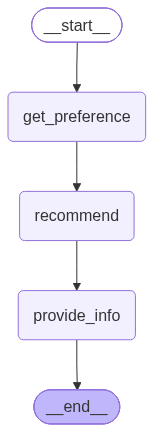

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### Branching Edge
- 현재 상태나 입력에 따라 다음 노드를 동적으로 결정하는 edge
- builder.add_conditional_edges() 사용

(1) State 정의
- 사용자 입력이 메뉴 추천이면 벡터저장소에서 검색하여 RAG CHAIN 실행하고, 
- 그렇지 않으면 LLM이 답변을 생성


In [2]:
from typing import List, TypedDict

# state schema definition
class MenuState(TypedDict):
    user_query: str
    is_menu_query: bool
    search_results: List[str]
    final_answer: str

(2) 벡터저장소 검색 도구
- 메뉴 검색을 위한 벡터 저장소를 로드

In [3]:
from pathlib import Path

from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

PROJECT_ROOT = Path.cwd().parent
CHROMA_DIR = PROJECT_ROOT / "chroma_db"
DATA_DIR = PROJECT_ROOT / "data"

embeddings_model = OllamaEmbeddings(model="qwen3-embedding:0.6b") 

# 기존 Chroma 저장소 로드
menu_db = Chroma(
    embedding_function = embeddings_model,
    collection_name = "restaurant_menu",
    persist_directory = str(CHROMA_DIR),
    )

(3) Node

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

gemini_llm = ChatGoogleGenerativeAI(model="gemini-3.8-flash", temperature=0)

def get_user_query(state: MenuState) -> MenuState:
    user_query = input("무엇을 도와드릴까요? ")
    return {"user_query": user_query}

def analyze_user_query(state: MenuState) -> MenuState:
    analyze_template = """
    사용자의 입력을 분석하여 레스토랑 메뉴 추천이나 음식 정보에 관한 질문인지 판단하세요.

    사용자 입력: {user_query}

    레스토랑 메뉴나 음식 정보에 관한 질문이면 "True", 아니면 "False"로 답변하세요.

    답변:
    """
    prompt = ChatPromptTemplate.from_template(analyze_template)
    chain = prompt | gemini_llm | StrOutputParser()

    result = chain.invoke({"user_query": state['user_query']})
    is_menu_query = result.strip().lower() == "true"

    return {"is_menu_query": is_menu_query}


def search_menu_info(state: MenuState) -> MenuState:
    # 벡터 저장소에서 최대 2개의 문서를 검색
    results = menu_db.similarity_search(state["user_query"], k = 2)
    searched = [doc.page_content for doc in results]

    return {"search_results":searched}

def generate_menu_response(state: MenuState) -> MenuState:
    response_template = """
    사용자 입력: {user_query}
    메뉴 관련 검색 결과: {search_results}

    위 정보를 바탕으로 사용자의 메뉴 관련 질문에 대한 상세한 답변을 생성하세요. 
    검색 결과의 정보를 활용하여 정확한 정보를 제공하세요. 

    답변:
    """
    response_prompt = ChatPromptTemplate.from_template(response_template)
    response_chain = response_prompt | gemini_llm | StrOutputParser()

    final_answer = response_chain.invoke({"user_query": state['user_query'], "search_results": state['search_results']})
    print(f"\nMenu Assistant: {final_answer}")

    return {"final_answer": final_answer}

def generate_general_response(state: MenuState) -> MenuState:
    response_template = """
    사용자 입력: {user_query}

    위 입력은 레스토랑 메뉴나 음식과 관련 이 없습니다. 
    일반적인 대화 맥락에서 적잘한 답변을 생성하세요. 

    답변:
    """
    response_prompt = ChatPromptTemplate.from_template(response_template)
    response_chain = response_prompt | gemini_llm | StrOutputParser()

    final_answer = response_chain.invoke({"user_query": state['user_query']})
    print(f"\nGenearl Assistant: {final_answer}")

    return {"final_answer": final_answer}


(4) Edges

In [5]:
# Restrict function argument to specific string choices
from typing import Literal 

def next_node(state: MenuState) -> Literal["search_menu_info", "generate_general_response"]:
    if state["is_menu_query"]:
        return "search_menu_info" # 함수 이름 반환
    else:
        return "generate_general_response" # 함수 이름 반환

### Graph 생성

In [9]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy

builder = StateGraph(MenuState)

builder.add_node("get_user_query", get_user_query)
builder.add_node("analyze_user_query", analyze_user_query, 
    retry_policy = RetryPolicy(max_attempts = 3, initial_interval = 1.0, backoff_factor = 2.0)
    )
builder.add_node("search_menu_info", search_menu_info)
builder.add_node("generate_menu_response", generate_menu_response)
builder.add_node("generate_general_response", generate_general_response)

builder.add_edge(START, "get_user_query")
builder.add_edge("get_user_query", "analyze_user_query")
builder.add_conditional_edges(
    "analyze_user_query", # 시작점
    next_node, # 조건부 분기 함수
    {"search_menu_info": "search_menu_info", "generate_general_response": "generate_general_response"} # 조건에 따른 다음 노드
)

builder.add_edge("search_menu_info", "generate_menu_response")
builder.add_edge("generate_menu_response", END)
builder.add_edge("generate_general_response", END)

graph = builder.compile()

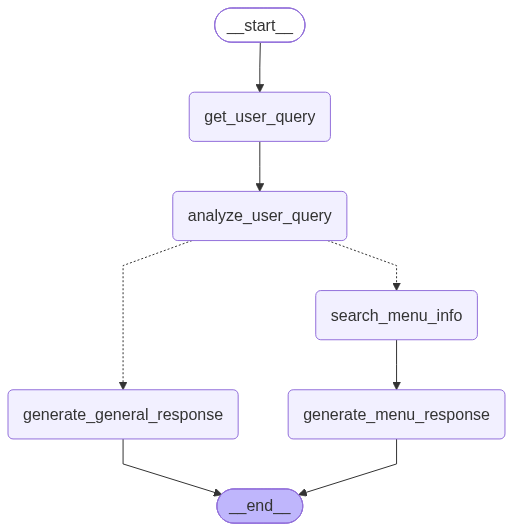

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
while True:
    initial_state = {"user_query": ""}
    graph.invoke(initial_state)

    continue_chat = input("다른 질문이 있으신가요? (y/n): ").lower()

    if continue_chat != "y":
        print("대화를 종료합니다. 감사합니다.")
        break


GoogleRateLimitError: Error calling model 'gemini-3.8-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.8-flash\nPlease retry in 21h6m33.664103163s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTie